---
# 🔀 **Dask for scalable data processing in the Cloud**

##### 🔶 This notebook introduces DASK, a Python library for parallel and distributed computing. Dask allows to scale up your Python code and data processing workflows to handle larger-than-memory datasets and leverage multiple cores. With the help of Dask, you can easily scale a wide array of solutions and configure your project to use most of the available computational power. It helps developers scale their entire Python ecosystem, and it can work with your laptop or a container cluster. The best part is that you don’t need to rewrite your entire codebase, you just have to enable parallel computing with minimal modifications based on your use cases.

*Below are the Key advantages of using Dask. It can,*

*- run your code in parallel on single machine/mutiple cores/cluster of machines.*

*- handle larger than memory datasets to process and analyze them efficiently.*

*- integrate seamlessly with popular Python libraries like NumPy, Pandas, and scikit-learn*

*- use a dynamic task scheduler to manage and optimize the execution of code*

*- collect the results from the executed tasks and combines them to produce the final output*

*In this demo, you will learn fundamentals for parallelizing Python codes and then deploy a Dask cluster on the cloud and connect from your GeoLab notebook*

*Below is a simplified overview of DASK architecture ⤵️*

***Scheduler ↔ Workers ↔ Client***

<img src="https://user-images.githubusercontent.com/306380/129031260-ad9600b0-1942-40ad-99a7-694ea2d3a382.jpg" alt="DASK" width="650"/> 

---

##### 🚩 USER To do 🚩
---
**In the next part, you need to make your workflows from 'intro.ipynb' notebook with directed acyclical graphs (DAGs), which are a type of graph where nodes are linked by one-way connections that do not form any cycles. DAGs are used to illustrate dependencies and causal relationships. This will help you to understand the DASK workflow in more details. The code is already eet-up, you just need to tweak the details**

---

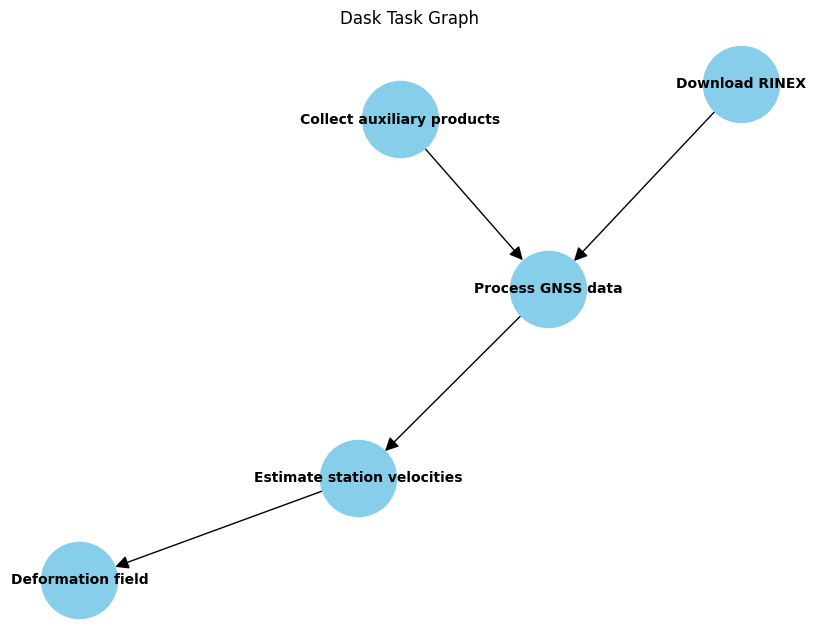

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Divide your workflow into different tasks
Task1 = 'Download RINEX'                    # Grab daily RINEX files for your network of stations.
Task2 = 'Collect auxiliary products'        # Fetch precise satellite ephemerides/clocks and local meteorological data needed for tropospheric corrections
Task3 = 'Process GNSS data'                 # Run your GNSS analysis software (e.g. GAMIT/GLOBK or GIPSY) to do quality control, cycle‐slip repair and compute daily station coordinates.
Task4 = 'Estimate station velocities'       # Fit the coordinate time series to extract long‐term trends (velocities), model seasonal signals, and characterize noise
Task5 = 'Deformation field'                 # Combine station velocities into a vector‐map of horizontal motion, interpret in terms of plate boundaries, strain accumulation, etc.

# Add nodes for tasks
G.add_node(Task1) # Grab daily RINEX files for your network of stations.
G.add_node(Task2)         
G.add_node(Task3)
G.add_node(Task4)
G.add_node(Task5)
# Add edges to show dependencies
G.add_edges_from([(Task1, Task3), (Task2, Task3), (Task3, Task4), (Task4, Task5)])

# Draw the graph
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="skyblue", font_size=10, font_weight="bold", arrowsize=20)

# Add title and labels
plt.title("Dask Task Graph")
plt.xlabel("Task Dependencies")
plt.ylabel("Execution Flow")

# Show the plot
plt.show()

### ☁️ Deploy DASK on the cloud

In [ ]:
import dask.dataframe as dd
from dask.distributed import Client


client = Client()
client

# Display the Dask dashboard link
print("Dask dashboard available at:", client.dashboard_link)

In [ ]:
# Get schema and Non-empty domain of Tdb object:
with tiledb.open(uri,mode="r", config=tdb_config,) as A:
    ned=A.nonempty_domain()
    # print(A.schema)

print(start)
start_t = time.time()
# This produces an array slice
def slice_tiledb(path, slc):
    with tiledb.open(uri,mode="r", config=tdb_config,) as A:
        return A[slc,0,:,12611]['snr']
        # return A[slc,:]['snr']
       

# Partition the array into delayed slices
chunk = 43200000*4 # tile size?
delayed_slices = list(
    dask.delayed(slice_tiledb)(uri, slice(int(start), int(start+chunk))) for 
                               start in 
                               np.arange(ned[0][0],ned[0][1]-chunk,step=chunk)) #-86400*1e3

# This creates a Dask array from the delayed slices
darray = dask.array.concatenate(
    dask.array.from_delayed(x,
                            shape=(chunk,), dtype=np.float64)
                            for x in delayed_slices)

#Everything up until here is lazy - nothing is really computed

# This triggers the entire computation
# print(darray.compute_chunk_sizes())
darray.persist()
gw_cluster = darray.mean().compute()

end_t = time.time()
gw_cluster_t=end_t - start_t

print('Object start date: ',utc_time(ned[0][0]))
print('Object end date: ',utc_time(ned[0][1]))

days_p=(ned[0][1]-ned[0][0])/(86400e3)
print('Processing %.01f days took %.01f seconds' %(days_p,gw_cluster_t))

fig, ax = plt.subplots(figsize=(8,4))
plt.bar(["Download and process: in GeoLab",
        "S3 and process: in GeoLab","Dask-Gateway in GeoLab"],
        [9,50,440])
plt.title("Amount of Days of GNSS Data Processed in about 30 seconds")
plt.xticks(rotation=90)
plt.show()